## Exploratory Data Analysis voor klachten train set
### Notebook EDA klachten classificatie voor correcte expertise

### Inhoud

1. [Introductie](#exploratory-data-analysis-voor-klachten-train-set)
2. [Data-Analyse](#data-analyse)
   - [Visualisaties](#visualisaties)
   - [Productsspecifieke-Analyse](#analyse-per-product)
   - [Featurespecifieke-Analyse](#analyse-per-specifieke-feature)
3. [Data_Preperation](#data-preperation)
   - [Wordclouds](#wordcloud-per-categorie)

In [26]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import numpy as np
import re
import matplotlib.pyplot as plt
import nltk

In [27]:
# imports
from sklearn.model_selection import train_test_split
from wordcloud import WordCloud
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.linear_model import LogisticRegression

In [28]:
# read training dataset
df = pd.read_csv("klacht_train.csv")

### Data Analyse

In [29]:
df.head().T

,0,1,2,3,4
ID,2290288,1638808,1374984,2325523,1375617
Datum_ontvangst,2025-01-15,2023-11-04,2023-05-14,2025-02-03,2023-05-14
Product,Kredietregistratie,Bankrekening,Incasso,Incasso,Incasso
Omschrijving,XXXX was reinserted on my credit report after ...,Huntington bank is doing it again. \r\nThey ar...,Company ordered a local minnesota repossession...,"This company called "" tecco Systems '' has bee...","On XXXX XXXX 2015, at approximately XXXX CST, ..."
Antwoord_bedrijf,Closed with explanation,Closed with explanation,Closed with explanation,Closed with explanation,Closed with explanation
Omschrijving_lengte,71,629,1410,1926,995
Antwoord_lengte,23,23,23,23,23


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9527 entries, 0 to 9526
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   9527 non-null   int64 
 1   Datum_ontvangst      9527 non-null   object
 2   Product              9527 non-null   object
 3   Omschrijving         9527 non-null   object
 4   Antwoord_bedrijf     9527 non-null   object
 5   Omschrijving_lengte  9527 non-null   int64 
 6   Antwoord_lengte      9527 non-null   int64 
dtypes: int64(3), object(4)
memory usage: 521.1+ KB


In [31]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,9527.0,1.905142e+06,340222.350721,1290157.0,1602900.5,1930144.0,2207545.0,2537437.0
Omschrijving_lengte,9527.0,1.026427e+03,915.343693,12.0,381.0,713.0,1374.5,10761.0
Antwoord_lengte,9527.0,2.378902e+01,3.946444,6.0,23.0,23.0,23.0,31.0


In [32]:
df['Product'].unique()

array(['Kredietregistratie', 'Bankrekening', 'Incasso', 'Hypotheek',
       'Consumentenkrediet', 'Creditcard'], dtype=object)

In [33]:
df['Antwoord_bedrijf'].unique()

array(['Closed with explanation', 'Closed with monetary relief',
       'Closed with non-monetary relief', 'Closed', 'Untimely response'],
      dtype=object)

In [34]:
df['Datum_ontvangst'].agg(['min', 'max'])

min    2023-03-19
max    2025-04-30
Name: Datum_ontvangst, dtype: object

In [35]:
df.shape
print("De dataset bevat {} rijen en {} kolommen.".format(df.shape[0], df.shape[1]))

De dataset bevat 9527 rijen en 7 kolommen.


In [36]:
# Numeriek
stats_num = df.describe(include='int64').T.reset_index().T
stats_num

,0,1,2
index,ID,Omschrijving_lengte,Antwoord_lengte
count,9527.0,9527.0,9527.0
mean,1905142.096883,1026.426997,23.789021
std,340222.350721,915.343693,3.946444
min,1290157.0,12.0,6.0
25%,1602900.5,381.0,23.0
50%,1930144.0,713.0,23.0
75%,2207545.0,1374.5,23.0
max,2537437.0,10761.0,31.0


In [37]:
# Categorisch
stats_cat = df.describe(include='object').T.reset_index()
stats_cat

,index,count,unique,top,freq
0,Datum_ontvangst,9527,770,2024-10-17,32
1,Product,9527,6,Incasso,2621
2,Omschrijving,9527,9497,I am filing this complaint because Experian ha...,5
3,Antwoord_bedrijf,9527,5,Closed with explanation,7414


In [38]:
# Verdeling verschillende expertises binnen de dataset
df['Product'].value_counts()

Product
Incasso               2621
Hypotheek             2108
Kredietregistratie    2072
Creditcard            1178
Bankrekening           946
Consumentenkrediet     602
Name: count, dtype: int64

In [39]:
train = pd.read_csv("klacht_train.csv")
test = pd.read_csv("klacht_test.csv")

In [40]:
train.isnull().sum()

ID                     0
Datum_ontvangst        0
Product                0
Omschrijving           0
Antwoord_bedrijf       0
Omschrijving_lengte    0
Antwoord_lengte        0
dtype: int64

In [41]:
train.duplicated().sum()

np.int64(0)

In [42]:
train.drop(columns=['ID']).describe().T

,count,mean,std,min,25%,50%,75%,max
Omschrijving_lengte,9527.0,1026.426997,915.343693,12.0,381.0,713.0,1374.5,10761.0
Antwoord_lengte,9527.0,23.789021,3.946444,6.0,23.0,23.0,23.0,31.0


#### Visualisaties

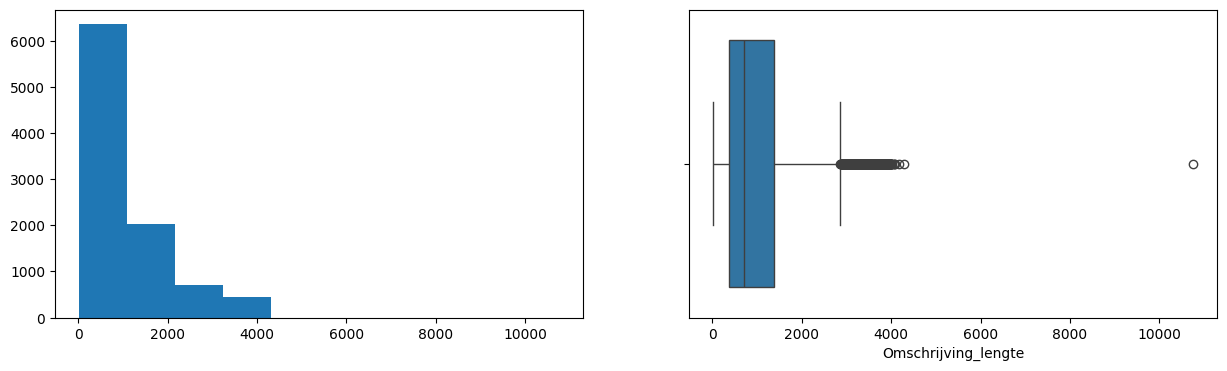

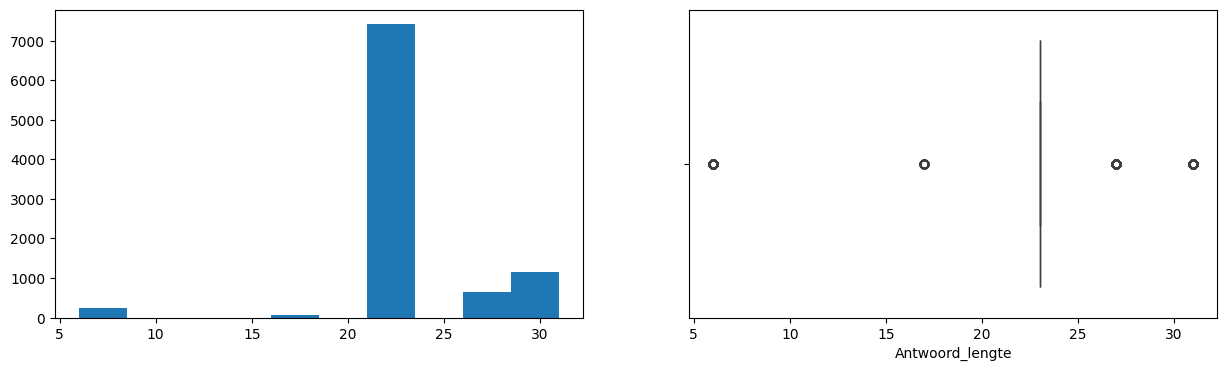

In [43]:
# bepaal numerieke variabelen
num_vars = train.drop(columns=['ID']).select_dtypes(include=np.number).columns.tolist()

# plot de verdeling van elke numerieke variabele in histogram en boxplot
for var in num_vars:
    plt.figure(figsize = (15, 4))
    plt.subplot(1, 2, 1)
    plt.hist(train[var])
    plt.subplot(1, 2, 2)
    sns.boxplot(x=train[var])
    plt.show()


In [44]:
train.select_dtypes(include="number").corr()

,ID,Omschrijving_lengte,Antwoord_lengte
ID,1.000000,0.005604,-0.001498
Omschrijving_lengte,0.005604,1.000000,-0.020285
Antwoord_lengte,-0.001498,-0.020285,1.000000


<Axes: >

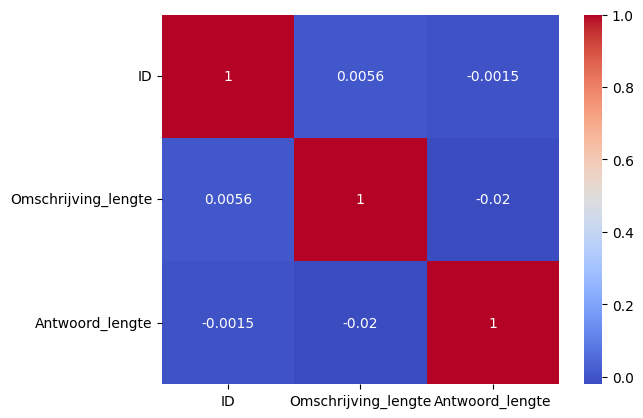

In [45]:
sns.heatmap(train.select_dtypes(include=np.number).corr(), annot=True, cmap="coolwarm")

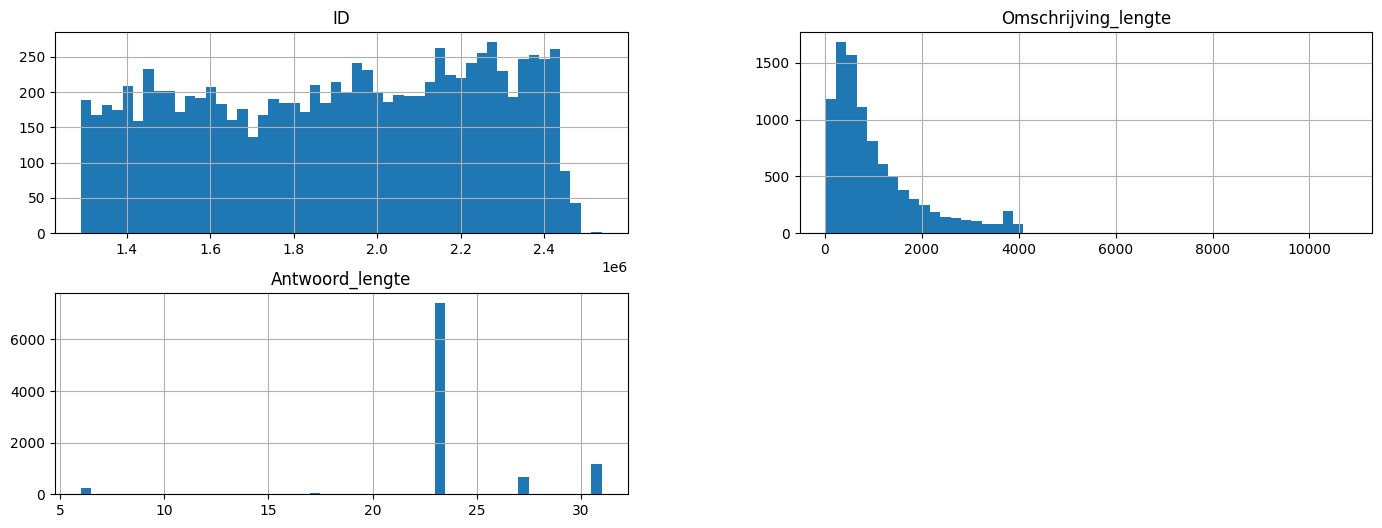

In [46]:
train.hist(bins=50, figsize=(17, 6))
plt.show()

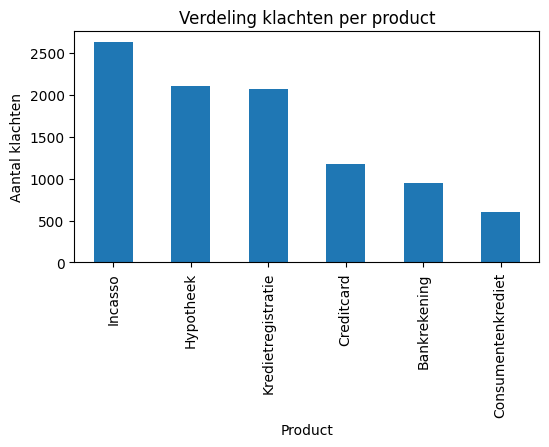

In [47]:
# Bar chart voor Product
plt.figure(figsize=(6,3))
train['Product'].value_counts().plot(kind="bar")
plt.title("Verdeling klachten per product")
plt.xlabel("Product")
plt.ylabel("Aantal klachten")
plt.show()

Incasso ontvangt de meeste klachten

### Analyse per product

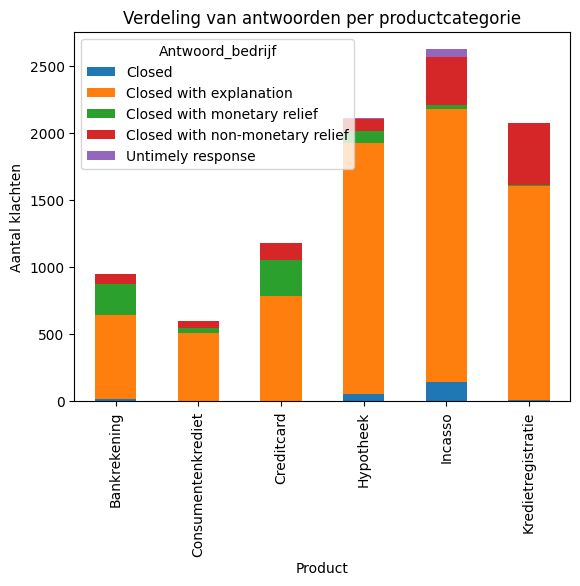

In [48]:
pd.crosstab(train["Product"], train["Antwoord_bedrijf"]).plot(kind="bar", stacked=True)
plt.title("Verdeling van antwoorden per productcategorie")
plt.ylabel("Aantal klachten")
plt.show()

## Data Preperation

#### Wordcloud per categorie

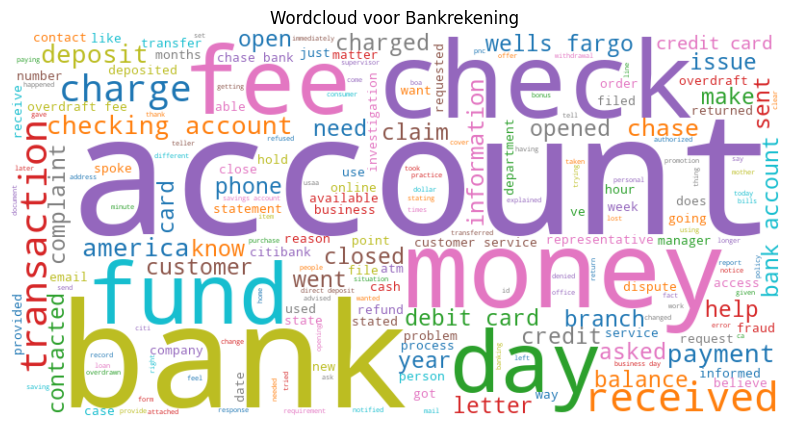

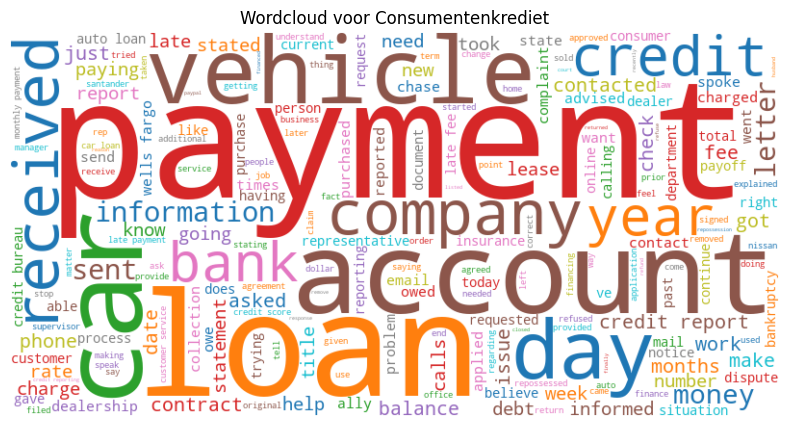

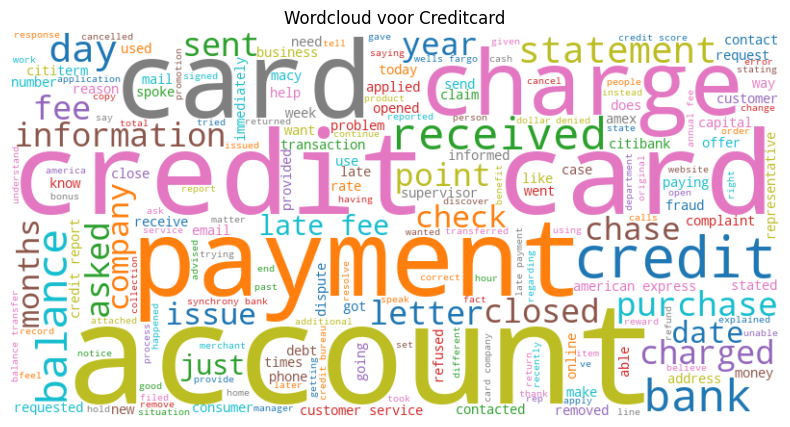

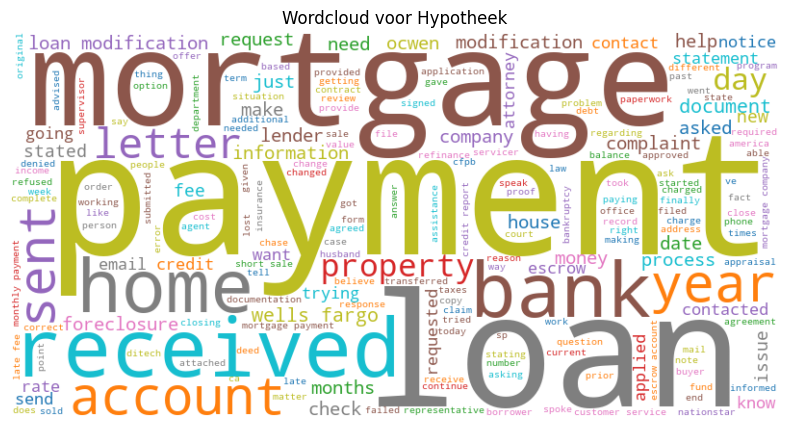

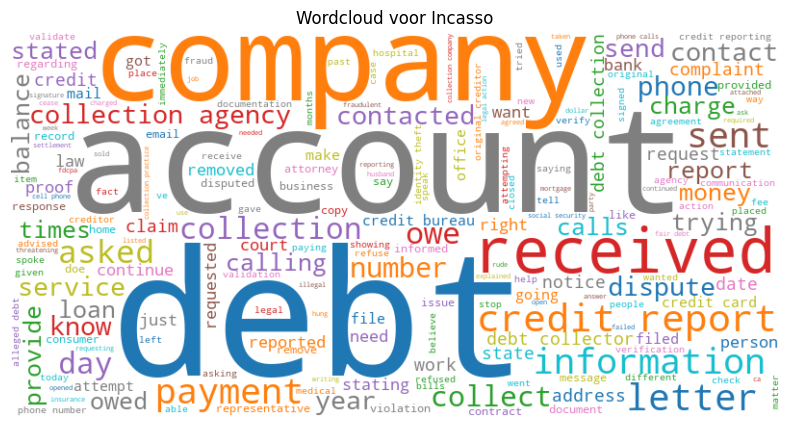

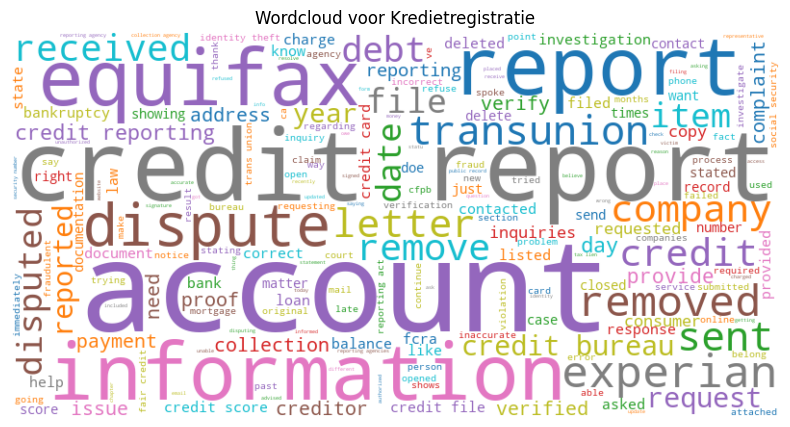

In [49]:
stopwoorden = list(set(ENGLISH_STOP_WORDS).union({
    'xxxx', 'xx', 'xxx', 'did', 'please', 'told', 'paid', 'called', 'time', 'said', 'month', 'pay',
    'a','b','c','d','e','f','g','h','i','j','k','l','m','n', 'o','p','q','r','s','t','u','v','w','x','y','z'
}))
#stopwoorden2 = set(stopwords.words("english"))

train["clean"] = train["Omschrijving"].fillna("").str.lower().str.replace(r'[^a-z\s]', ' ', regex=True)

vectorizer = TfidfVectorizer(stop_words=stopwoorden, max_features=1000)
tfidf = vectorizer.fit_transform(train["clean"])
woorden = vectorizer.get_feature_names_out()

train["Top_keywords"] = [
    [woorden[i] for i in tfidf[row].toarray()[0].argsort()[-5:][::-1]]
    for row in range(tfidf.shape[0])
]

for product, groep in train.groupby("Product"):
    tekst = " ".join(groep["clean"])
    wc = WordCloud(width=800, height=400, background_color="white",
                   stopwords=set(stopwoorden), colormap="tab10").generate(tekst)
    plt.figure(figsize=(10,5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Wordcloud voor {product}")
    plt.show()